# Airbnb Market Intelligence

# 07 - Correlation Analysis

## Objectives

- Analyze correlations between numerical features
- Identify variables affecting price
- Detect multicollinearity
- Generate business insights

## Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Load Dataset

In [2]:
df = pd.read_csv("../data/cleaned/listings_cleaned.csv")

print(df.shape)

df.head()

(279712, 32)


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279712 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                279712 non-null  object 
 5   host_response_time           279712 non-null  object 
 6   host_response_rate           279712 non-null  float64
 7   host_acceptance_rate         279712 non-null  float64
 8   host_is_superhost            279712 non-null  object 
 9   host_total_listings_count    279712 non-null  float64
 10  host_has_profile_pic         279712 non-null  object 
 11  host_identity_verified       279712 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [4]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.columns

Index(['listing_id', 'host_id', 'host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'latitude', 'longitude', 'accommodates',
       'bedrooms', 'price', 'minimum_nights', 'maximum_nights',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value'],
      dtype='object')

In [5]:
corr = numeric_df.corr()
corr

,listing_id,host_id,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
listing_id,1.000000,0.582679,-0.074085,0.010613,0.071958,-0.012022,-0.001949,-0.005969,0.000335,0.011471,-0.034967,-0.005873,0.014310,0.021545,0.057850,-0.004819,-0.006633,0.070089,0.066076
host_id,0.582679,1.000000,-0.085177,0.067138,0.015210,0.005266,0.008961,-0.014839,-0.004954,0.011795,-0.038348,-0.003148,-0.040920,-0.027145,0.016917,-0.040881,-0.043512,0.008242,0.012060
host_response_rate,-0.074085,-0.085177,1.000000,0.215414,0.013520,0.016625,0.010092,-0.040176,-0.032990,-0.010305,0.008363,0.000926,0.044328,0.036673,0.021260,0.037199,0.049761,0.020142,0.023964
host_acceptance_rate,0.010613,0.067138,0.215414,1.000000,0.011209,0.057661,0.026676,-0.044810,-0.049346,-0.024715,-0.008650,-0.000020,-0.018176,-0.011929,-0.002172,-0.015019,-0.010307,-0.013117,-0.006327
host_total_listings_count,0.071958,0.015210,0.013520,0.011209,1.000000,-0.042249,0.061711,-0.018863,-0.011920,0.009909,-0.000158,-0.000303,0.004145,0.010951,0.021387,0.007872,0.006004,0.017336,0.017170
latitude,-0.012022,0.005266,0.016625,0.057661,-0.042249,1.000000,-0.417783,-0.111880,-0.143691,-0.099278,0.046801,0.001569,-0.033826,-0.015729,-0.040722,-0.026853,-0.017074,-0.044847,-0.031387
longitude,-0.001949,0.008961,0.010092,0.026676,0.061711,-0.417783,1.000000,0.009465,0.035391,0.019608,-0.056316,-0.001410,-0.030354,-0.025981,-0.014397,-0.022772,-0.015090,-0.025844,-0.008844
accommodates,-0.005969,-0.014839,-0.040176,-0.044810,-0.018863,-0.111880,0.009465,1.000000,0.636699,0.146327,-0.033442,0.003241,0.000038,-0.015594,-0.005763,-0.002984,-0.007300,-0.001682,-0.029589
bedrooms,0.000335,-0.004954,-0.032990,-0.049346,-0.011920,-0.143691,0.035391,0.636699,1.000000,0.141627,-0.011317,0.000405,0.014723,0.000489,0.013517,0.010509,0.003098,0.011023,-0.000154
price,0.011471,0.011795,-0.010305,-0.024715,0.009909,-0.099278,0.019608,0.146327,0.141627,1.000000,0.006344,-0.000442,0.015730,0.013437,0.029954,0.010815,0.009198,0.013503,0.020143


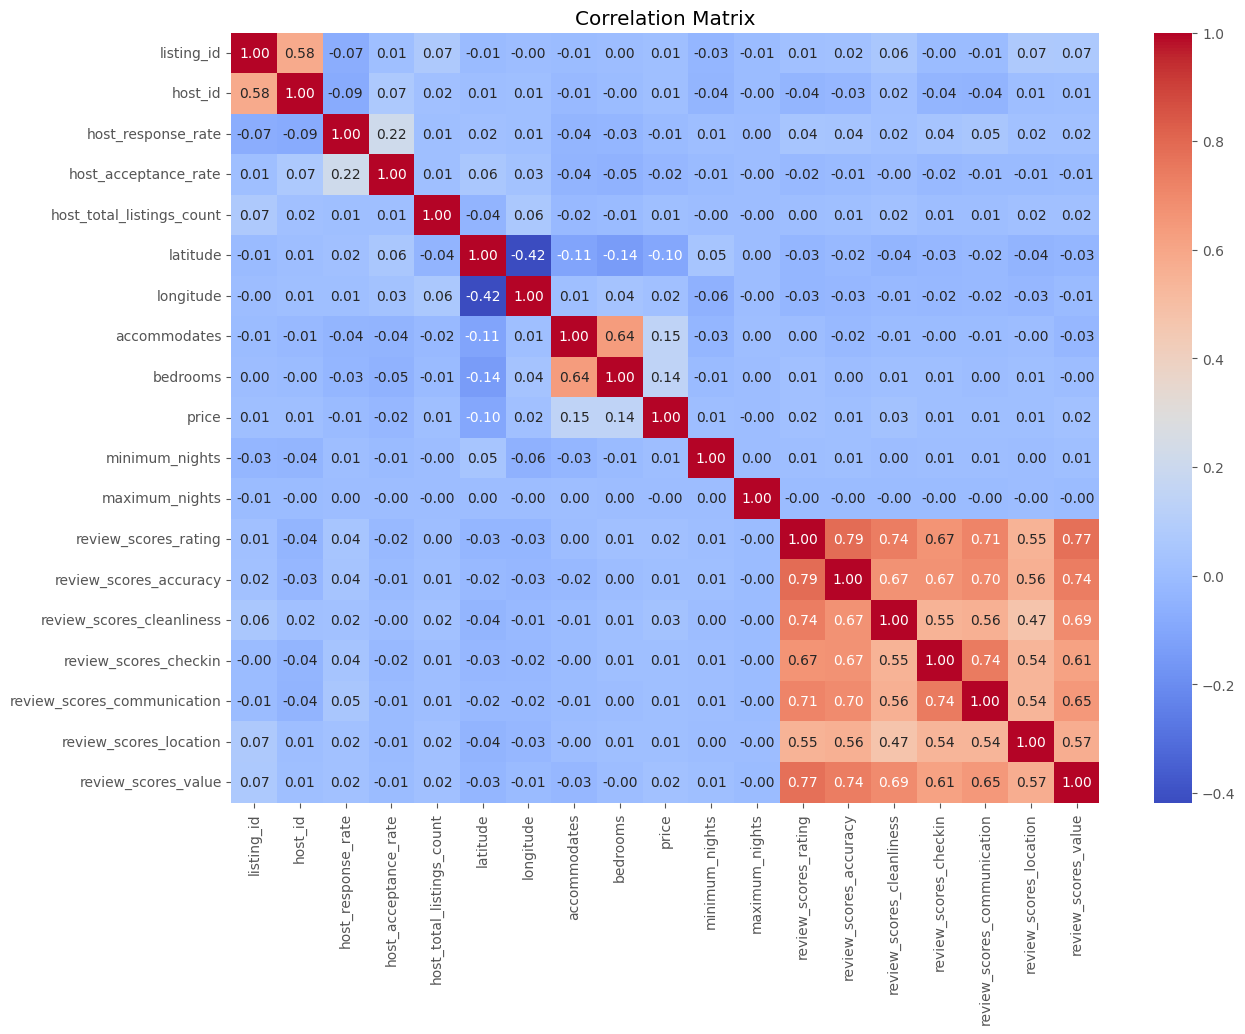

In [6]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [7]:
price_corr = (
    corr["price"]
    .sort_values(ascending=False)
)

price_corr

price                          1.000000
accommodates                   0.146327
bedrooms                       0.141627
review_scores_cleanliness      0.029954
review_scores_value            0.020143
longitude                      0.019608
review_scores_rating           0.015730
review_scores_location         0.013503
review_scores_accuracy         0.013437
host_id                        0.011795
listing_id                     0.011471
review_scores_checkin          0.010815
host_total_listings_count      0.009909
review_scores_communication    0.009198
minimum_nights                 0.006344
maximum_nights                -0.000442
host_response_rate            -0.010305
host_acceptance_rate          -0.024715
latitude                      -0.099278
Name: price, dtype: float64

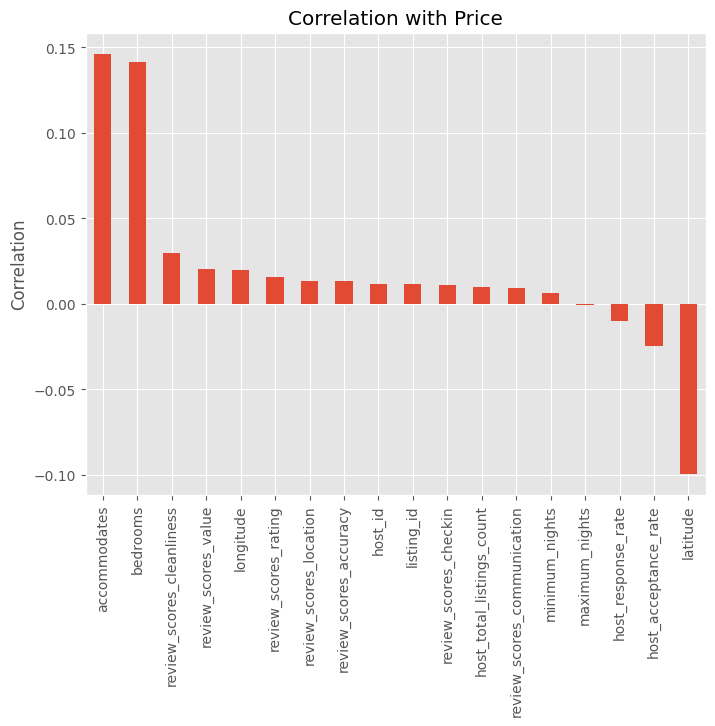

In [8]:
plt.figure(figsize=(8,6))

price_corr.drop("price").plot(kind="bar")

plt.title("Correlation with Price")

plt.ylabel("Correlation")

plt.show()

In [9]:
strong_corr = corr.unstack()

strong_corr = strong_corr[
    (abs(strong_corr) > 0.50) &
    (abs(strong_corr) < 1)
]

strong_corr.sort_values(ascending=False)

review_scores_accuracy       review_scores_rating           0.786388
review_scores_rating         review_scores_accuracy         0.786388
                             review_scores_value            0.772935
review_scores_value          review_scores_rating           0.772935
review_scores_checkin        review_scores_communication    0.744256
review_scores_communication  review_scores_checkin          0.744256
review_scores_cleanliness    review_scores_rating           0.737098
review_scores_rating         review_scores_cleanliness      0.737098
review_scores_value          review_scores_accuracy         0.735276
review_scores_accuracy       review_scores_value            0.735276
review_scores_rating         review_scores_communication    0.714064
review_scores_communication  review_scores_rating           0.714064
                             review_scores_accuracy         0.695201
review_scores_accuracy       review_scores_communication    0.695201
review_scores_value          revie

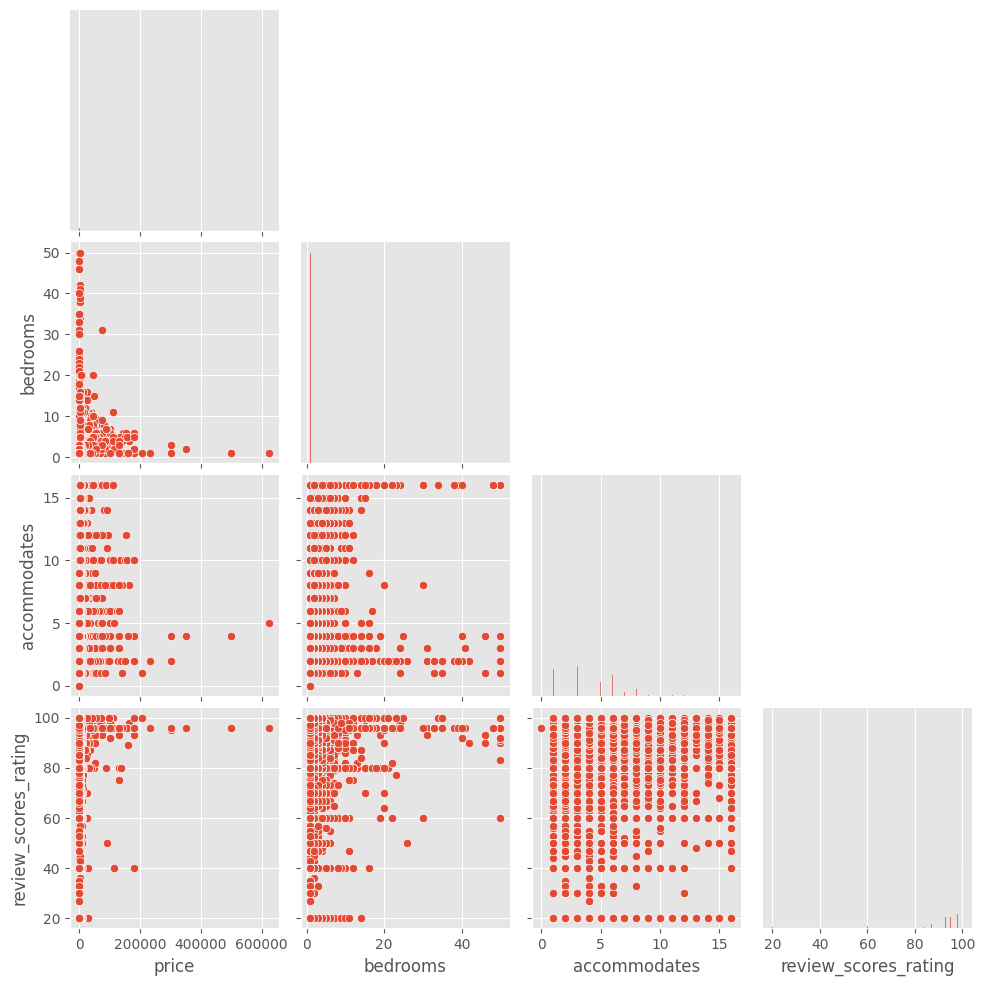

In [10]:
cols = [
    "price",
    "bedrooms",
    "accommodates",
    "review_scores_rating"
]

sns.pairplot(
    df[cols],
    corner=True
)

plt.show()

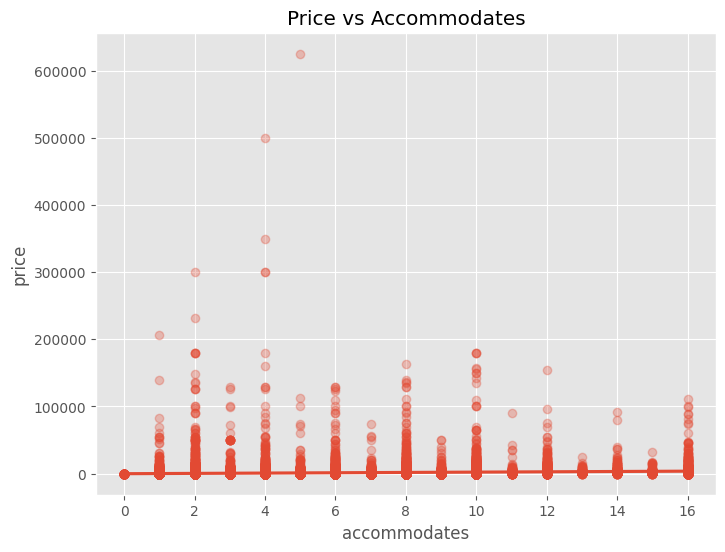

In [11]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="accommodates",
    y="price",
    scatter_kws={"alpha":0.3}
)

plt.title("Price vs Accommodates")

plt.show()

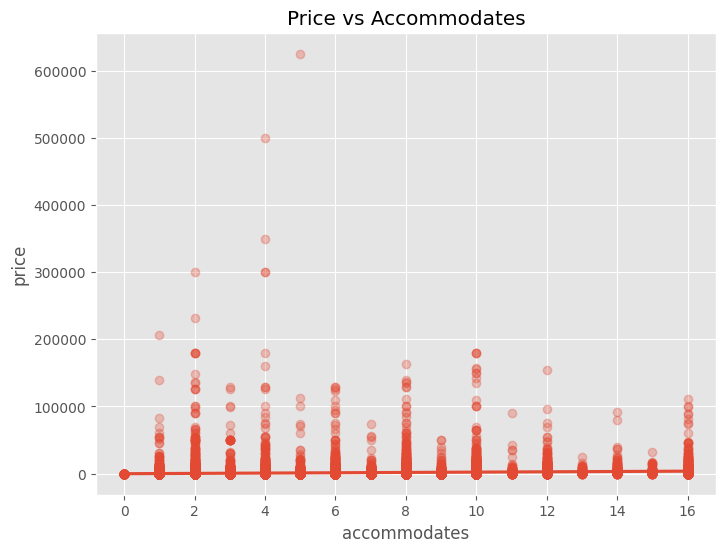

In [12]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="accommodates",
    y="price",
    scatter_kws={"alpha":0.3}
)

plt.title("Price vs Accommodates")

plt.show()

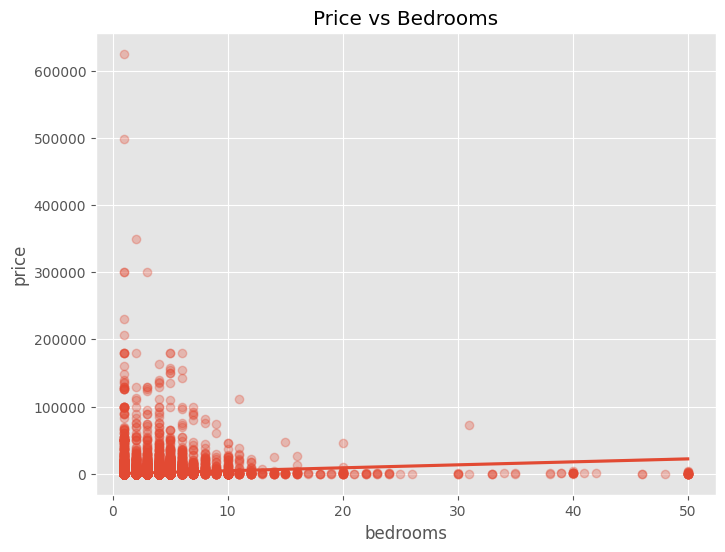

In [13]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="bedrooms",
    y="price",
    scatter_kws={"alpha":0.3}
)

plt.title("Price vs Bedrooms")

plt.show()

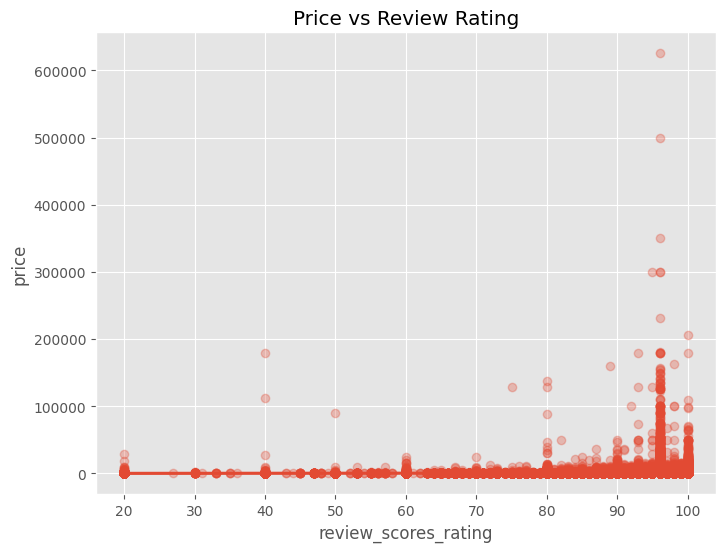

In [14]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="review_scores_rating",
    y="price",
    scatter_kws={"alpha":0.3}
)

plt.title("Price vs Review Rating")

plt.show()

In [15]:
correlation_table = (
    corr["price"]
    .sort_values(ascending=False)
    .reset_index()
)

correlation_table.columns = [
    "Feature",
    "Correlation"
]

correlation_table

,Feature,Correlation
0,price,1.000000
1,accommodates,0.146327
2,bedrooms,0.141627
3,review_scores_cleanliness,0.029954
4,review_scores_value,0.020143
5,longitude,0.019608
6,review_scores_rating,0.015730
7,review_scores_location,0.013503
8,review_scores_accuracy,0.013437
9,host_id,0.011795


In [16]:
correlation_table.to_csv(
    "../reports/correlation_analysis.csv",
    index=False
)

print("Correlation report saved.")

Correlation report saved.


# Key Insights

### Price Drivers
- Accommodates generally has a positive relationship with price.
- Bedrooms also tend to increase price.
- Review ratings often have a weaker relationship with price.

### Multicollinearity
- Accommodates and bedrooms may be correlated.
- Review score components are often strongly correlated with each other.

### Business Value
- Property capacity is an important pricing factor.
- Quality metrics help explain customer satisfaction more than pricing.